In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
from sklearn.metrics import mean_squared_error, r2_score
# Load the dataset
data = pd.read_csv('Data.csv')
# Display the first few rows of the dataset
print(data.head())


   Taxi_dist  Market_dist  Hospital_dist  Carpet_area  Builtup_area  \
0     9796.0       5250.0        10703.0       1659.0        1961.0   
1     8294.0       8186.0        12694.0       1461.0        1752.0   
2    11001.0      14399.0        16991.0       1340.0        1609.0   
3     8301.0      11188.0        12289.0       1451.0        1748.0   
4    10510.0      12629.0        13921.0       1770.0        2111.0   

   Parking_type City_type  Rainfall  Price_house  
0          Open     CAT B       530      6649000  
1  Not Provided     CAT B       210      3982000  
2  Not Provided     CAT A       720      5401000  
3       Covered     CAT B       620      5373000  
4  Not Provided     CAT B       450      4662000  


In [2]:
print("Dataset shape :-",data.shape)
print("Data Columns :-",data.columns.tolist())
print("Information about the dataset :-",data.info())

Dataset shape :- (932, 9)
Data Columns :- ['Taxi_dist', 'Market_dist', 'Hospital_dist', 'Carpet_area', 'Builtup_area', 'Parking_type', 'City_type', 'Rainfall', 'Price_house']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 932 entries, 0 to 931
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Taxi_dist      919 non-null    float64
 1   Market_dist    919 non-null    float64
 2   Hospital_dist  931 non-null    float64
 3   Carpet_area    924 non-null    float64
 4   Builtup_area   917 non-null    float64
 5   Parking_type   932 non-null    object 
 6   City_type      932 non-null    object 
 7   Rainfall       932 non-null    int64  
 8   Price_house    932 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 65.7+ KB
Information about the dataset :- None


In [4]:
#statistical summary of the dataset
print("Statistical summary of the dataset :-\n",data.describe())

Statistical summary of the dataset :-
           Taxi_dist   Market_dist  Hospital_dist   Carpet_area  Builtup_area  \
count    919.000000    919.000000     931.000000    924.000000    917.000000   
mean    8229.727965  11018.752992   13072.092374   1511.862554   1794.924755   
std     2561.985008   2543.920590    2586.456161    790.969660    468.159457   
min      146.000000   1666.000000    3227.000000    775.000000    932.000000   
25%     6476.000000   9354.500000   11301.500000   1318.000000   1583.000000   
50%     8230.000000  11161.000000   13163.000000   1480.500000   1774.000000   
75%     9937.000000  12670.500000   14817.000000   1655.000000   1982.000000   
max    20662.000000  20945.000000   23294.000000  24300.000000  12730.000000   

          Rainfall   Price_house  
count   932.000000  9.320000e+02  
mean    785.579399  6.084695e+06  
std     265.546853  5.025364e+06  
min    -110.000000  3.000000e+04  
25%     600.000000  4.658000e+06  
50%     780.000000  5.866000e+

In [5]:
#check null values in the dataset
print("Null values in the dataset :-\n",data.isnull().sum())
#check duplicated values in the dataset
print("Duplicated values in the dataset :-\n",data.duplicated().sum())

Null values in the dataset :-
 Taxi_dist        13
Market_dist      13
Hospital_dist     1
Carpet_area       8
Builtup_area     15
Parking_type      0
City_type         0
Rainfall          0
Price_house       0
dtype: int64
Duplicated values in the dataset :-
 0


In [8]:
#handling the missing values 
numeric_cols = ['Taxi_dist', 'Market_dist', 'Hospital_dist',
                'Carpet_area', 'Builtup_area']

for col in numeric_cols:
    data[col].fillna(data[col].median(), inplace=True)

#verify the missing values are handled
print("Null values in the dataset after handling :-\n",data.isnull().sum())

Null values in the dataset after handling :-
 Taxi_dist        0
Market_dist      0
Hospital_dist    0
Carpet_area      0
Builtup_area     0
Parking_type     0
City_type        0
Rainfall         0
Price_house      0
dtype: int64


C:\Users\Bhavani\AppData\Local\Temp\ipykernel_47212\2713358994.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [11]:
#handling categorical values in dataset
#check unique values in the categorical column

print("Unique values in 'Parking_type' column :-",data['Parking_type'].unique())
print("Unique values in 'Facing' column :-",data['City_type'].unique())

#Check counts
print("count of parking type :-",data['Parking_type'].value_counts())
print("count of city type :-",data['City_type'].value_counts())


Unique values in 'Parking_type' column :- ['Open' 'Not Provided' 'Covered' 'No Parking']
Unique values in 'Facing' column :- ['CAT B' 'CAT A' 'CAT C']
count of parking type :- Parking_type
Open            372
Not Provided    227
Covered         188
No Parking      145
Name: count, dtype: int64
count of city type :- City_type
CAT B    365
CAT A    329
CAT C    238
Name: count, dtype: int64


In [13]:
data = pd.get_dummies(
    data,
    columns=['Parking_type', 'City_type'],
    drop_first=True
)

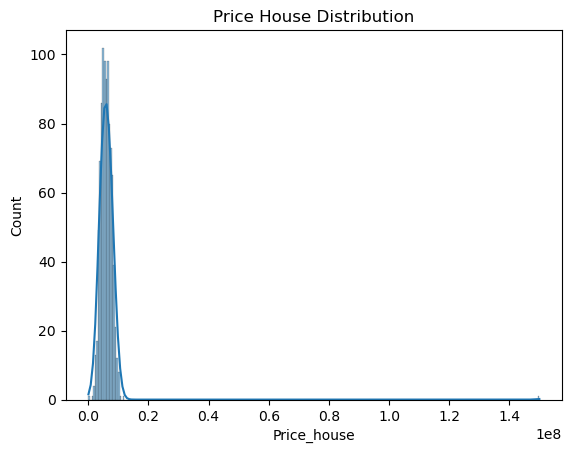

In [14]:
#Target variable distribution
sns.histplot(data['Price_house'], kde=True)

plt.title("Price House Distribution")

plt.show()

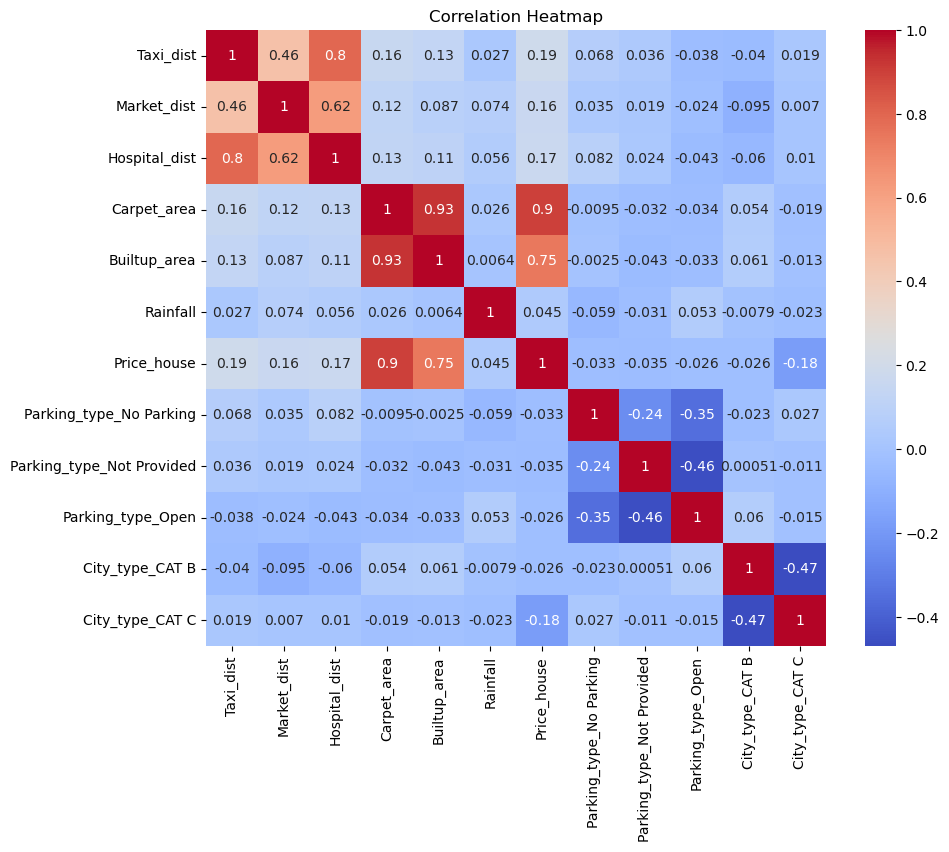

In [16]:
#Correlation heatmap ( to check  which features are  strongly effect the target variable (house price))
plt.figure(figsize=(10,8))

sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [17]:
#Carpet_area, Builtup_area  are strongly correlated with the target variable (Price_house) and also they are strongly correlated with each other.

from sklearn.metrics import mean_absolute_error
X = data.drop("Price_house", axis=1) #Input feature

y = data["Price_house"] # output feature 

#Train test split 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
#Train model
model=LinearRegression()
model.fit(X_train,y_train)
#Predicting the test set results
y_pred=model.predict(X_test)

#Evaluate the model
mae=mean_absolute_error(y_pred,y_test)
print("Mean absolute error:-",mae)
mse=mean_squared_error(y_pred,y_test)
print("Mean Squared Error:-",mse)
r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)

Mean absolute error:- 1016065.7237483552
Mean Squared Error:- 1632221962936.3186
R2 Score : 0.4181527462567839


Text(0.5, 1.0, 'Actual Vs Predicted')

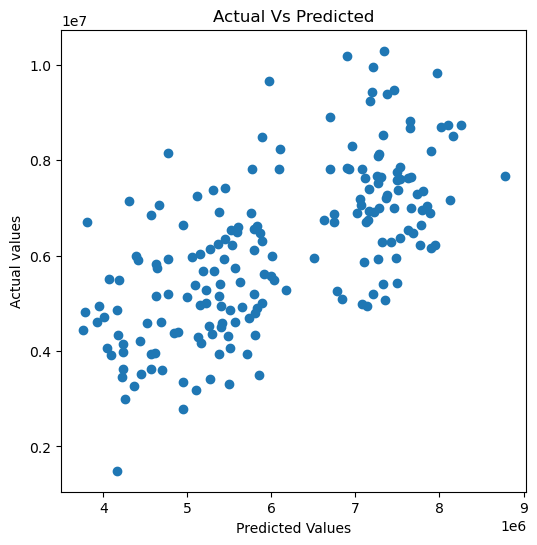

In [19]:
#Actual Vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_pred,y_test)
plt.ylabel("Actual values")
plt.xlabel("Predicted Values")
plt.title("Actual Vs Predicted")

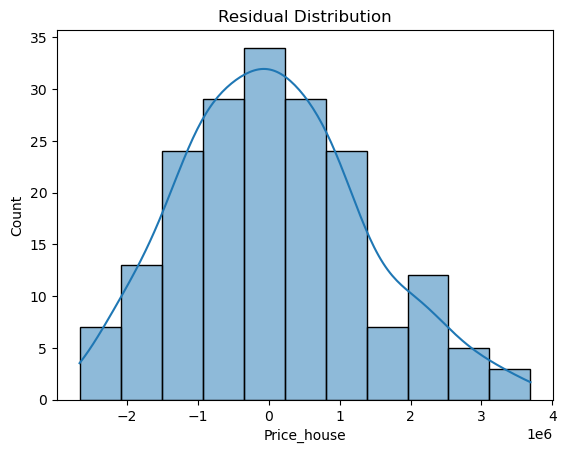

In [ ]:
#Residuals Analysis:- it helps to check wherther regiression model working properly?

residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")

plt.show()

In [23]:
#Save the model 
import pickle 
pickle.dump(model, open('linear_model.pkl','wb'))